# Final Project: Detecting Fake Job Postings Using Machine Learning
**Group Members:** Sudheesh Sreenilayam & Hemanth Kavali

### The Goal
Our project aims to build an automated system that can detect whether a job posting is **Real** or **Fake**.

We will:
1.  **Collect Data:** Scrape live job postings from the web (Internshala.com).
2.  **Train a Model:** Use a large kaggle dataset of known fake/real jobs to teach the model how to spot scams.
3.  **Test the System:** Feed our scraped jobs into the model to see if it works in the real world.

## Phase 1: Data Collection

### Step 1: Import Libraries
We need three main tools:
* `requests`: To visit websites and download their HTML code.
* `BeautifulSoup`: To read that HTML and find the specific data we want.
* `pandas`: To organize our data into neat tables (like Excel).

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from IPython.display import display

print("Libraries imported successfully.")

Libraries imported successfully.


### Step 2: Connect to the Website
We will write a script to visit **Internshala**, a popular internship website. We use a "User-Agent" so the website thinks we are a normal human using a web browser, not a robot.

In [ ]:
URL = "https://internshala.com/internships/web-development-internship/"

# This header is essential to make the server think we are a real browser
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

print(f"Fetching URL: {URL}")
response = requests.get(URL, headers=headers)

if response.status_code == 200:
    print("Success! We downloaded the page.")
    # Parse the HTML content
    soup = BeautifulSoup(response.content, 'html.parser')
else:
    print(f"Failed to retrieve the page. Status code: {response.status_code}")

Fetching URL: https://internshala.com/internships/web-development-internship/
Success! We downloaded the page.


### Step 3: Extract the Job Details
Now that we have the website's code, we need to find the specific pieces of information.

We looked at the website's HTML and found these patterns:
* Job Titles are inside `<a>` tags with the class `job-title-href`.
* Company Names are inside `<p>` tags with the class `company-name`.
* Locations are inside `<div>` tags with the class `locations`.

The code below finds every job card and pulls out these three details.

In [ ]:
titles = []
companies = []
locations = []

# Find all the main job containers
job_cards = soup.find_all('div', class_='individual_internship')
print(f"Found {len(job_cards)} job postings on the page.")

for card in job_cards:
    # 1. Find the title
    title_element = card.find('a', class_='job-title-href')

    # 2. Find the company
    company_element = card.find('p', class_='company-name')

    # 3. Find the location
    location_div = card.find('div', class_='locations')
    location_element = None # Initialize as None
    if location_div:
        location_element = location_div.find('a')

    # Check if all three elements were successfully found
    if title_element and company_element and location_element:
        titles.append(title_element.get_text(strip=True))
        companies.append(company_element.get_text(strip=True))
        locations.append(location_element.get_text(strip=True))
    else:
        # This will skip any cards that are missing data (like ads)
        pass

print(f"Successfully extracted {len(titles)} complete job postings.")

Found 51 job postings on the page.
Successfully extracted 50 complete job postings.


### Step 4: Save to CSV
We successfully grabbed the data! Now we will organize it into a DataFrame (a table) and save it as a file named `scraped_internshala_jobs.csv`.

We will use this file later to test our machine learning model.

In [ ]:
if titles:
    df = pd.DataFrame({
        'Job Title': titles,
        'Company': companies,
        'Location': locations
    })

    df.to_csv('scraped_internshala_jobs.csv', index=False)
    print("Data successfully saved to 'scraped_internshala_jobs.csv'")

    # Display the first 5 rows in our notebook for the demo
    print("\n--- Sample of Scraped Data ---")
    display(df.head())

else:
    print("No valid job postings were extracted.")

print("Script finished.")

Data successfully saved to 'scraped_internshala_jobs.csv'

--- Sample of Scraped Data ---


,Job Title,Company,Location
0,Artificial Intelligence (AI),SANVER INDIA PRIVATE LIMITED,Mumbai
1,Python Django Developer,Tradexa Technologies Private Limited,Pune
2,Artificial Intelligence (AI),Zoxima Solutions Private Limited,Noida
3,Full-Stack Web Development,El Codamics,Tamil Nadu
4,Mobile App Development,Ace 360,Mumbai


Script finished.


# Phase 2: Pre-processing & Feature Engineering

### Step 1: Get the Training Data
We scraped 50 jobs for testing, but we need *thousands* of jobs to train a smart model.

We are using the **"Real / Fake Job Posting Prediction"** dataset from Kaggle. It contains 17,880 labeled job postings. The code below downloads this dataset directly into our notebook.

In [ ]:
import os
from google.colab import files

# --- 1. Install Kaggle and Set Up API ---
print("Installing Kaggle library...")
!pip install -q kaggle

print("\nPlease upload your 'kaggle.json' file:")
# Prompt user to upload the kaggle.json file
uploaded = files.upload()

# Check if file was uploaded
if 'kaggle.json' not in uploaded:
    print("\nError: 'kaggle.json' file not found. Please run this cell again.")
else:
    print("\n'kaggle.json' uploaded successfully.")

    # --- 2. Configure Kaggle API ---
    # Create the .kaggle directory and move the file
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/

    # Set permissions for the file (this is required by Kaggle)
    !chmod 600 ~/.kaggle/kaggle.json
    print("Kaggle API configured.")

    # --- 3. Download the Dataset ---
    print("Downloading 'Real / Fake Job Posting Prediction' dataset...")
    !kaggle datasets download -d shivamb/real-or-fake-fake-jobposting-prediction

    # --- 4. Unzip the Dataset ---
    print("Unzipping dataset...")
    # The file is named 'real-or-fake-fake-jobposting-prediction.zip'
    !unzip -q real-or-fake-fake-jobposting-prediction.zip

    print("\n--- Success! ---")
    print("The file 'fake_job_postings.csv' is now in your Colab environment.")
    print("\nYou are ready for the next step: Loading and Inspecting.")

Installing Kaggle library...

Please upload your 'kaggle.json' file:


Saving kaggle.json to kaggle.json

'kaggle.json' uploaded successfully.
Kaggle API configured.
Dataset URL: https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction
License(s): CC0-1.0
  0% 0.00/16.1M [00:00<?, ?B/s]
100% 16.1M/16.1M [00:00<00:00, 936MB/s]
Unzipping dataset...

--- Success! ---
The file 'fake_job_postings.csv' is now in your Colab environment.

You are ready for the next step: Loading and Inspecting.


### Step 2: Load and Inspect the Data
We load the Kaggle data to understand what we are working with.

**Key Observations:**
1.  **Missing Data:** Columns like `salary_range` and `department` are mostly empty.
2.  **Class Imbalance:** As the chart below will show, **95%** of jobs are Real and only **5%** are Fake. This makes it hard for a model to find the fakes.

--- 1. Loading 'fake_job_postings.csv' ---
Kaggle dataset loaded successfully.
Shape of the training data (rows, columns): (17880, 18)


--- 2. Initial Inspection (First 5 Rows) ---
   job_id                                      title            location  \
0       1                           Marketing Intern    US, NY, New York   
1       2  Customer Service - Cloud Video Production      NZ, , Auckland   
2       3    Commissioning Machinery Assistant (CMA)       US, IA, Wever   
3       4          Account Executive - Washington DC  US, DC, Washington   
4       5                        Bill Review Manager  US, FL, Fort Worth   

  department salary_range  \
0  Marketing          NaN   
1    Success          NaN   
2        NaN          NaN   
3      Sales          NaN   
4        NaN          NaN   

                                                                                       company_profile  \
0  We're Food52, and we've created a groundbreaking and award-winning cooking si

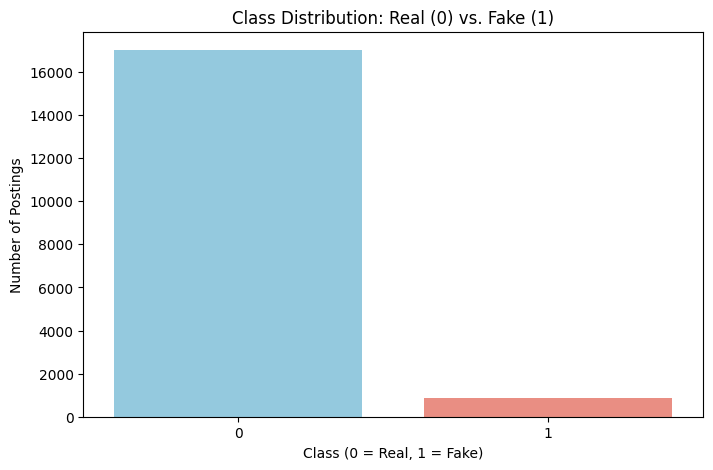

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set options for better display
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 100)

# --- 1. Load the Kaggle Dataset ---
print("--- 1. Loading 'fake_job_postings.csv' ---")
try:
    df_train = pd.read_csv('fake_job_postings.csv')
    print("Kaggle dataset loaded successfully.")
    print(f"Shape of the training data (rows, columns): {df_train.shape}")
    print("\n")
except FileNotFoundError:
    print("Error: 'fake_job_postings.csv' not found.")
    print("Please make sure you ran the 'Download Kaggle Dataset' cell first.")
    df_train = None
except Exception as e:
    print(f"An error occurred: {e}")
    df_train = None

if df_train is not None:
    # --- 2. Initial Inspection (Head) ---
    print("--- 2. Initial Inspection (First 5 Rows) ---")
    print(df_train.head())
    print("\n")

    # --- 3. Check for Missing Values (CRITICAL for our project) ---
    print("--- 3. Missing Values Check (.info()) ---")
    print("This shows us the 'meta-features' we can create.")
    print("Columns with < 17880 non-null values are missing data.")
    df_train.info()
    print("\n")

    # --- 4. Check Class Imbalance (CRITICAL for our project) ---
    print("--- 4. Class Imbalance Check (Target: 'fraudulent') ---")
    # 0 = Real, 1 = Fake
    class_counts = df_train['fraudulent'].value_counts()
    print(class_counts)
    print("\n")

    # --- 5. Visualize the Imbalance ---
    print("--- 5. Visualizing Class Imbalance ---")
    plt.figure(figsize=(8, 5))

    # --- THIS LINE IS THE FIX ---
    # We follow the FutureWarning: add hue='fraudulent' and legend=False
    sns.countplot(x='fraudulent', data=df_train, hue='fraudulent', palette={0: 'skyblue', 1: 'salmon'}, legend=False)
    # --- END OF FIX ---

    plt.title('Class Distribution: Real (0) vs. Fake (1)')
    plt.ylabel('Number of Postings')
    plt.xlabel('Class (0 = Real, 1 = Fake)')

    # Add annotations
    total = len(df_train)
    real_pct = (class_counts[0] / total) * 100
    fake_pct = (class_counts[1] / total) * 100

    print(f"Percentage Real: {real_pct:.2f}%")
    print(f"Percentage Fake: {fake_pct:.2f}%")
    print("This is the 'class imbalance' we will have to solve.")

    plt.show()

### Step 3: Fix Missing Data
We have a lot of empty cells (NaN). We can't just delete them because we'd lose too much data.

**Our Strategy:**
* Fill the empty text cells with a blank space so our code doesn't crash.
* **Insight:** We realized that *missing* information is actually a clue! Fake jobs often leave out details. We will use this in the next step.

In [ ]:
import pandas as pd
import numpy as np

if 'df_train' in locals() or 'df_train' in globals():
    print("--- 6. Starting Step 3: Filling Missing Text ---")

    # Defining all columns that contain text
    text_cols = [
        'title', 'location', 'department', 'salary_range', 'company_profile',
        'description', 'requirements', 'benefits', 'employment_type',
        'required_experience', 'required_education', 'industry', 'function'
    ]

    # Loop through each text column and fill NaN with a blank space
    original_na_counts = {}
    for col in text_cols:
        if col in df_train.columns:
            original_na_counts[col] = df_train[col].isna().sum()
            df_train[col] = df_train[col].fillna(' ')

    print("Missing text data filled with blank spaces.")
    print("Example: 'department' missing count (before):", original_na_counts.get('department'))
    print("Example: 'department' missing count (after):", df_train['department'].isna().sum())

    print("\n--- Step 3 Complete ---")

else:
    print("Error: DataFrame 'df_train' not found.")
    print("Please run the previous cells to load the data first.")

--- 6. Starting Step 3: Filling Missing Text ---
Missing text data filled with blank spaces.
Example: 'department' missing count (before): 11547
Example: 'department' missing count (after): 0

--- Step 3 Complete ---


### Step 4: Create "Meta-Features" (The Flags)
Since missing data is a clue, we are turning it into a feature the model can understand.

We are creating new "Flag" columns (0 or 1):
* `has_company_logo`: 1 if present, 0 if missing.
* `has_salary_range`: 1 if present, 0 if missing.

These **Meta-Features** will help the model spot scams that look "too empty."

In [ ]:
import pandas as pd

# Assuming 'df_train' is already loaded and NA-filled
if 'df_train' in locals() or 'df_train' in globals():
    print("--- 7. Starting Step 4: Creating Meta-Features ---")

    # Create new features based on whether the (now-filled) text is just a blank space
    df_train['has_department'] = (df_train['department'] != ' ').astype(int)
    df_train['has_salary_range'] = (df_train['salary_range'] != ' ').astype(int)
    df_train['has_company_profile'] = (df_train['company_profile'] != ' ').astype(int)
    df_train['has_requirements'] = (df_train['requirements'] != ' ').astype(int)
    df_train['has_benefits'] = (df_train['benefits'] != ' ').astype(int)
    df_train['has_employment_type'] = (df_train['employment_type'] != ' ').astype(int)
    df_train['has_required_experience'] = (df_train['required_experience'] != ' ').astype(int)
    df_train['has_required_education'] = (df_train['required_education'] != ' ').astype(int)
    df_train['has_industry'] = (df_train['industry'] != ' ').astype(int)
    df_train['has_function'] = (df_train['function'] != ' ').astype(int)

    print("New binary 'meta-features' created.")

    # Display the first few rows of our new features
    print("\n--- Example of New Features ---")
    new_features = [
        'has_department', 'has_salary_range', 'has_company_profile',
        'has_requirements', 'has_benefits'
    ]
    print(df_train[new_features].head())

    print("\n--- Step 4 Complete ---")

else:
    print("Error: DataFrame 'df_train' not found.")
    print("Please run the previous cells first.")

--- 7. Starting Step 4: Creating Meta-Features ---
New binary 'meta-features' created.

--- Example of New Features ---
   has_department  has_salary_range  has_company_profile  has_requirements  \
0               1                 0                    1                 1   
1               1                 0                    1                 1   
2               0                 0                    1                 1   
3               1                 0                    1                 1   
4               0                 0                    1                 1   

   has_benefits  
0             0  
1             1  
2             0  
3             1  
4             1  

--- Step 4 Complete ---


### Step 5: Combine All Text
A machine learning model reads a document as one big block of text.

We are taking all the separate text columns (Title, Description, Requirements, etc.) and gluing them together into one giant column called `text_corpus`. This represents the "entire story" of the job posting.

In [ ]:
import pandas as pd

# Assuming 'df_train' is already loaded and features are engineered
if 'df_train' in locals() or 'df_train' in globals():
    print("--- 8. Starting Step 5: Consolidating Text ---")

    # Grab all the original text columns (we already filled their NaNs)
    text_cols = [
        'title', 'location', 'department', 'salary_range', 'company_profile',
        'description', 'requirements', 'benefits', 'employment_type',
        'required_experience', 'required_education', 'industry', 'function'
    ]

    # Create the 'text_corpus' by joining all text columns with a space
    df_train['text_corpus'] = df_train[text_cols].apply(lambda x: ' '.join(x), axis=1)

    print("Text consolidation complete.")
    print("\n--- Example of a single 'text_corpus' entry: ---")
    print(df_train['text_corpus'].iloc[0])

    print("\n--- Step 5 Complete ---")

else:
    print("Error: DataFrame 'df_train' not found.")
    print("Please run the previous cells first.")

--- 8. Starting Step 5: Consolidating Text ---
Text consolidation complete.

--- Example of a single 'text_corpus' entry: ---
Marketing Intern US, NY, New York Marketing   We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly curated information about food and cooking. We attract the most talented home cooks and contributors in the country; we also publish well-known professionals like Mario Batali, Gwyneth Paltrow, and Danny Meyer. And we have partnerships with Whole Foods Market and Random House.Food52 has been named the best food website by the James Beard Foundation and IACP, and has been featured in the New York Times, NPR, Pando Daily, TechCrunch, and on t

### Step 6: Text Cleaning (Normalization)
Computers are very literal. They think "Manager" and "manager!" are different words.

We are cleaning the text to make it consistent:
1.  **Lowercase:** Make everything lowercase.
2.  **Remove Noise:** Delete all punctuation, numbers, and special symbols.

In [ ]:
import pandas as pd
import re
from tqdm import tqdm # A library to show a progress bar

# Register tqdm for pandas .apply()
tqdm.pandas(desc="Cleaning Text p1")

# Assuming 'df_train' is ready with 'text_corpus'
if 'df_train' in locals() or 'df_train' in globals():
    print("--- 9. Starting Step 6: Text Cleaning (Lowercase & Punctuation) ---")

    def clean_text_p1(text):
        # 1. Convert to lowercase
        text = text.lower()

        # 2. Remove punctuation, numbers, and special characters
        # This regex keeps only letters (a-z) and spaces
        text = re.sub(r'[^a-z\s]', '', text)

        # 3. Remove extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()

        return text

    # Apply this function to every row in 'text_corpus'
    print("Applying p1 cleaning (lowercase, punctuation, numbers)...")
    df_train['text_corpus_clean'] = df_train['text_corpus'].progress_apply(clean_text_p1)

    print("Text cleaning (p1) complete.")
    print("\n--- Example of Cleaned Text (p1) ---")
    print("Original:", df_train['text_corpus'].iloc[0])
    print("Cleaned:", df_train['text_corpus_clean'].iloc[0])

    print("\n--- Step 6 Complete ---")

else:
    print("Error: DataFrame 'df_train' not found.")
    print("Please run the previous cells first.")

--- 9. Starting Step 6: Text Cleaning (Lowercase & Punctuation) ---
Applying p1 cleaning (lowercase, punctuation, numbers)...


Cleaning Text p1: 100%|██████████| 17880/17880 [00:04<00:00, 3708.08it/s]

Text cleaning (p1) complete.

--- Example of Cleaned Text (p1) ---
Original: Marketing Intern US, NY, New York Marketing   We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly curated information about food and cooking. We attract the most talented home cooks and contributors in the country; we also publish well-known professionals like Mario Batali, Gwyneth Paltrow, and Danny Meyer. And we have partnerships with Whole Foods Market and Random House.Food52 has been named the best food website by the James Beard Foundation and IACP, and has been featured in the New York Times, NPR, Pando Daily, TechCrunch, and on the Today Show.We're located in Chelsea, in New Yo

### Step 7: Text Cleaning (Stopwords)
Words like "the," "and," "is," and "to" appear in every job posting. They don't help us tell if a job is fake. These are called **Stopwords**.

We are using the NLTK library to remove them. This leaves us with only the important keywords like "python," "marketing," or "immediate."

In [ ]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from tqdm import tqdm

# Register tqdm for pandas .apply()
tqdm.pandas(desc="Cleaning Text p2")

# --- 7a. Download NLTK Stopwords ---
print("--- 10. Starting Step 7: Text Cleaning (Stopwords) ---")
print("Downloading NLTK stopwords...")
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
print("Stopwords downloaded.")

# --- 7b. Define Stopword Removal Function ---
def remove_stopwords(text):
    # Split text into words
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Re-join words into a clean string
    return ' '.join(words)

# --- 7c. Apply the Function ---
# Assuming 'df_train' is ready with 'text_corpus_clean' from the previous step
if 'df_train' in locals() or 'df_train' in globals():
    print("Applying p2 cleaning (stopwords)...")

    # We apply this to the *already cleaned* text
    df_train['text_corpus_clean'] = df_train['text_corpus_clean'].progress_apply(remove_stopwords)

    print("Text cleaning (p2) complete.")

    print("\n--- Example of Final Cleaned Text ---")
    print("Original:", df_train['text_corpus'].iloc[0])
    print("Final Cleaned:", df_train['text_corpus_clean'].iloc[0])

    print("\n--- Phase 2 (Data Pre-processing) Complete! ---")
    print("We are now ready for TF-IDF and modeling.")

else:
    print("Error: DataFrame 'df_train' not found.")
    print("Please run the previous cells first.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


--- 10. Starting Step 7: Text Cleaning (Stopwords) ---
Stopwords downloaded.
Applying p2 cleaning (stopwords)...


Cleaning Text p2: 100%|██████████| 17880/17880 [00:01<00:00, 15788.29it/s]

Text cleaning (p2) complete.

--- Example of Final Cleaned Text ---
Original: Marketing Intern US, NY, New York Marketing   We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly curated information about food and cooking. We attract the most talented home cooks and contributors in the country; we also publish well-known professionals like Mario Batali, Gwyneth Paltrow, and Danny Meyer. And we have partnerships with Whole Foods Market and Random House.Food52 has been named the best food website by the James Beard Foundation and IACP, and has been featured in the New York Times, NPR, Pando Daily, TechCrunch, and on the Today Show.We're located in Chelsea, in New Y

# Phase 3: Machine Learning Modeling

### Step 8: Split the Data
Before we train, we must split our data into two sets:
1.  **Training Set (80%):** The data the model studies to learn.
2.  **Testing Set (20%):** The data we hide from the model to test it later.

This ensures we get an honest score of how well the model works.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Assuming 'df_train' is ready from the previous steps
if 'df_train' in locals() or 'df_train' in globals():
    print("--- 11. Starting Step 8: Splitting Data ---")

    # --- 8a. Define our features (X) and target (y) ---

    # The target variable
    y = df_train['fraudulent']

    # The meta-features (numeric)
    meta_feature_columns = [
        'telecommuting', 'has_company_logo', 'has_questions',
        'has_department', 'has_salary_range', 'has_company_profile',
        'has_requirements', 'has_benefits', 'has_employment_type',
        'has_required_experience', 'has_required_education',
        'has_industry', 'has_function'
    ]

    # Ensure all columns exist, just in case
    meta_feature_columns = [col for col in meta_feature_columns if col in df_train.columns]

    X_meta_features = df_train[meta_feature_columns]

    # The text feature (NLP)
    X_text = df_train['text_corpus_clean']

    # --- 8b. Create the train/test split ---
    # We split all features and the target at the same time
    # This ensures the indices are aligned

    X_train_text, X_test_text, \
    X_train_meta, X_test_meta, \
    y_train, y_test = train_test_split(
        X_text,
        X_meta_features,
        y,
        test_size=0.2,    # 20% of data for testing
        random_state=42,  # For reproducible results
        stratify=y        # IMPORTANT: Ensures the 5% fake/real split is in both train and test sets
    )

    print("Data split complete.")
    print(f"Training set size: {len(y_train)} rows")
    print(f"Testing set size:  {len(y_test)} rows")

    print("\nTraining set class distribution:")
    print(y_train.value_counts(normalize=True))

    print("\nTesting set class distribution:")
    print(y_test.value_counts(normalize=True))

    print("\n--- Step 8 Complete ---")

else:
    print("Error: DataFrame 'df_train' not found.")
    print("Please run the previous cells first.")

--- 11. Starting Step 8: Splitting Data ---
Data split complete.
Training set size: 14304 rows
Testing set size:  3576 rows

Training set class distribution:
fraudulent
0    0.951552
1    0.048448
Name: proportion, dtype: float64

Testing set class distribution:
fraudulent
0    0.951622
1    0.048378
Name: proportion, dtype: float64

--- Step 8 Complete ---


### Step 9: Turn Text into Numbers (TF-IDF)
Our model can't read English. We use **TF-IDF** to convert words into numbers.

* **TF (Term Frequency):** Counts how often a word appears in a job.
* **IDF (Inverse Document Frequency):** Lowers the score of common words (like "work") and boosts unique words (like "bitcoin").

This creates a matrix of numbers representing the "importance" of every word.

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Assuming X_train_text and X_test_text exist from the previous cell
if 'X_train_text' in locals() or 'X_train_text' in globals():
    print("--- 12. Starting Step 9: TF-IDF Vectorization ---")

    # --- 9a. Initialize the TF-IDF Vectorizer ---
    # We set a max_features limit to keep our model fast and prevent
    # it from learning "too rare" words. 5000 is a good starting point.
    tfidf_vectorizer = TfidfVectorizer(max_features=5000)

    # --- 9b. Fit and Transform the TRAINING data ---
    print("Fitting TF-IDF on training text...")
    X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)

    # --- 9c. Only Transform the TESTING data ---
    print("Transforming testing text...")
    X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

    print("TF-IDF vectorization complete.")
    print(f"Shape of training text features (rows, features): {X_train_tfidf.shape}")
    print(f"Shape of testing text features (rows, features): {X_test_tfidf.shape}")

    print("\n--- Step 9 Complete ---")

else:
    print("Error: 'X_train_text' not found.")
    print("Please run Step 8 (Split Data) first.")

--- 12. Starting Step 9: TF-IDF Vectorization ---
Fitting TF-IDF on training text...
Transforming testing text...
TF-IDF vectorization complete.
Shape of training text features (rows, features): (14304, 5000)
Shape of testing text features (rows, features): (3576, 5000)

--- Step 9 Complete ---


### Step 10: Combine Everything
We now have two sets of data:
1.  The **TF-IDF Text Scores**.
2.  The **Meta-Feature Flags** (has_logo, has_salary, etc.).

We combine them into one final, giant matrix. This is the complete picture of every job posting that we will feed to the model.

In [ ]:
from scipy.sparse import hstack
import numpy as np

# Assuming X_train_tfidf, X_test_tfidf, X_train_meta, and X_test_meta exist
if 'X_train_tfidf' in locals() or 'X_train_tfidf' in globals():
    print("--- 13. Starting Step 10: Combining All Features ---")

    # --- 10a. Combine Training Features ---
    # hstack joins sparse matrices. We need to make sure our meta features are
    # in the right format.
    print("Combining training TF-IDF and meta-features...")
    X_train_final = hstack((X_train_tfidf, X_train_meta.astype(float)))

    # --- 10b. Combine Testing Features ---
    print("Combining testing TF-IDF and meta-features...")
    X_test_final = hstack((X_test_tfidf, X_test_meta.astype(float)))

    print("Feature combination complete.")
    print(f"Shape of final training matrix: {X_train_final.shape}")
    print(f"Shape of final testing matrix: {X_test_final.shape}")

    print(f"\nTotal features: {X_train_final.shape[1]} (5000 from text + {X_train_meta.shape[1]} from meta)")

    print("\n--- Step 10 Complete ---")

else:
    print("Error: Feature matrices not found.")
    print("Please run Step 8 and 9 first.")

--- 13. Starting Step 10: Combining All Features ---
Combining training TF-IDF and meta-features...
Combining testing TF-IDF and meta-features...
Feature combination complete.
Shape of final training matrix: (14304, 5013)
Shape of final testing matrix: (3576, 5013)

Total features: 5013 (5000 from text + 13 from meta)

--- Step 10 Complete ---


### Step 11: Fix Imbalance (SMOTE)
Remember that only 5% of our jobs are fake? That's a problem. A model could just guess "Real" every time and be 95% correct.

We use **SMOTE** (Synthetic Minority Over-sampling Technique) to fix this.
* It doesn't just copy fake jobs.
* It mathematically generates *new* examples of fake jobs.

**Result:** Our training data is now perfectly balanced: **50% Real / 50% Fake**.

--- 14. Starting Step 11: Applying SMOTE ---
Original training set shape: (14304, 5013)
Original training class distribution:
fraudulent
0    13611
1      693
Name: count, dtype: int64

Applying SMOTE to oversample the minority class (1)...
SMOTE complete.

--- Output After SMOTE ---
New resampled training set shape: (27222, 5013)

New resampled training class distribution:
fraudulent
0    13611
1    13611
Name: count, dtype: int64

Balance Check:
Real (0): 50.00%
Fake (1): 50.00%
--- 5. Visualizing Class Imbalance ---

--- Step 11 Complete ---


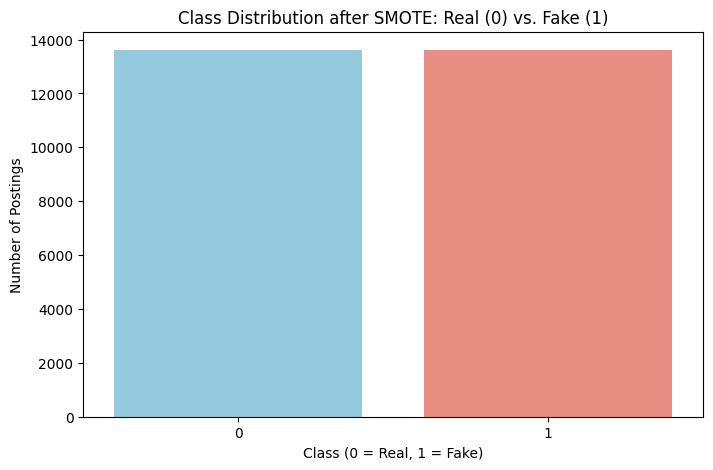

In [ ]:
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming X_train_final and y_train exist
if 'X_train_final' in locals() or 'X_train_final' in globals():
    print("--- 14. Starting Step 11: Applying SMOTE ---")

    print(f"Original training set shape: {X_train_final.shape}")
    print("Original training class distribution:")
    print(y_train.value_counts())

    # --- 11a. Initialize SMOTE ---
    # random_state for reproducible results
    smote = SMOTE(random_state=42)

    # --- 11b. Fit and Resample ---
    print("\nApplying SMOTE to oversample the minority class (1)...")
    # This may take a moment
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_final, y_train)

    print("SMOTE complete.")

    # --- 11c. Output after SMOTE ---
    print("\n--- Output After SMOTE ---")
    print(f"New resampled training set shape: {X_train_resampled.shape}")

    print("\nNew resampled training class distribution:")
    resampled_counts = pd.Series(y_train_resampled).value_counts()
    print(resampled_counts)

    # Calculate and print the percentage balance to confirm 50/50 split
    total_resampled = len(y_train_resampled)
    real_pct = resampled_counts[0] / total_resampled * 100
    fake_pct = resampled_counts[1] / total_resampled * 100

    print(f"\nBalance Check:")
    print(f"Real (0): {real_pct:.2f}%")
    print(f"Fake (1): {fake_pct:.2f}%")

    print("--- 5. Visualizing Class Imbalance ---")
    plt.figure(figsize=(8, 5))

    # Convert y_train_resampled Series to a DataFrame for seaborn
    df_resampled_plot = pd.DataFrame(y_train_resampled, columns=['fraudulent'])
    sns.countplot(x='fraudulent', data=df_resampled_plot, hue='fraudulent', palette={0: 'skyblue', 1: 'salmon'}, legend=False)
    # --- FIX END ---

    plt.title('Class Distribution after SMOTE: Real (0) vs. Fake (1)')
    plt.ylabel('Number of Postings')
    plt.xlabel('Class (0 = Real, 1 = Fake)')

    print("\n--- Step 11 Complete ---")

else:
    print("Error: 'X_train_final' not found.")
    print("Please run the previous steps first.")


### Step 12: Model 1 - Logistic Regression
We start with a simple baseline model.

* **Training:** We teach it using our balanced SMOTE data.
* **Testing:** We test it on the original, real-world data.

**The Metric:** We care most about **Recall** (did we catch the fakes?) and **Precision** (did we avoid flagging real jobs?).

--- 15. Starting Step 12: Model 1 (Logistic Regression) ---
Training Logistic Regression model on resampled data...
Model training complete.
Making predictions on the unseen test set...

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      3403
           1       0.65      0.89      0.75       173

    accuracy                           0.97      3576
   macro avg       0.82      0.93      0.87      3576
weighted avg       0.98      0.97      0.97      3576


--- Confusion Matrix ---


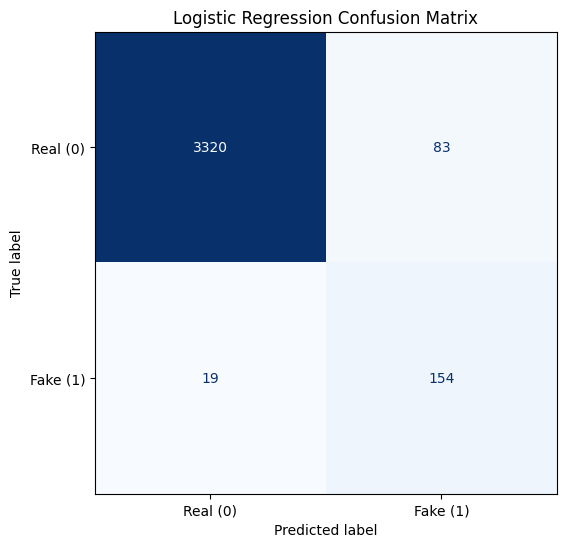


--- Step 12 Complete: Baseline Model Done ---


In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Assuming all previous steps are complete
if 'X_train_resampled' in locals() or 'X_train_resampled' in globals():
    print("--- 15. Starting Step 12: Model 1 (Logistic Regression) ---")

    # --- 12a. Initialize and Train the Model ---
    print("Training Logistic Regression model on resampled data...")
    # Increase max_iter as the dataset is large
    lr_model = LogisticRegression(max_iter=1000, random_state=42)
    lr_model.fit(X_train_resampled, y_train_resampled)
    print("Model training complete.")

    # --- 12b. Make Predictions on the TEST set ---
    print("Making predictions on the unseen test set...")
    y_pred_lr = lr_model.predict(X_test_final)

    # --- 12c. Evaluate the Model ---
    print("\n--- Logistic Regression Classification Report ---")
    # This report is the most important output!
    # We focus on the '1' (fake) row: Precision, Recall, F1-Score
    print(classification_report(y_test, y_pred_lr))

    print("\n--- Confusion Matrix ---")
    # This shows us *what* we got right and wrong
    # TN | FP
    # FN | TP
    cm = confusion_matrix(y_test, y_pred_lr)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real (0)', 'Fake (1)'])

    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    plt.title("Logistic Regression Confusion Matrix")
    plt.show()

    print("\n--- Step 12 Complete: Baseline Model Done ---")

else:
    print("Error: Resampled training data not found.")
    print("Please run all previous steps first.")

### Step 13: Model 2 - Random Forest
Now we try a more powerful model. Random Forest builds hundreds of small "decision trees" and lets them vote.

We expect this model to be "smarter" and have higher Precision (fewer false alarms) than the first one.

--- 16. Starting Step 13: Model 2 (Random Forest) ---
Training Random Forest model on resampled data...
Model training complete.
Making predictions on the unseen test set...

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       0.99      0.69      0.81       173

    accuracy                           0.98      3576
   macro avg       0.99      0.84      0.90      3576
weighted avg       0.98      0.98      0.98      3576


--- Confusion Matrix ---


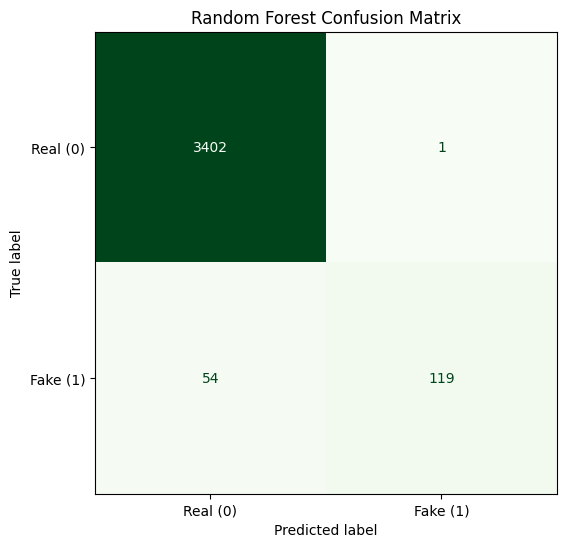


--- Step 13 Complete ---


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Assuming X_train_resampled, y_train_resampled, X_test_final, and y_test exist
if 'X_train_resampled' in locals() or 'X_train_resampled' in globals():
    print("--- 16. Starting Step 13: Model 2 (Random Forest) ---")

    # --- 13a. Initialize and Train the Model ---
    print("Training Random Forest model on resampled data...")
    # n_jobs=-1 uses all available CPU cores to speed up training
    rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

    # This may take a bit longer than Logistic Regression
    rf_model.fit(X_train_resampled, y_train_resampled)
    print("Model training complete.")

    # --- 13b. Make Predictions on the TEST set ---
    print("Making predictions on the unseen test set...")
    y_pred_rf = rf_model.predict(X_test_final)

    # --- 13c. Evaluate the Model ---
    print("\n--- Random Forest Classification Report ---")
    # Let's see if this is better than our 0.75 baseline!
    print(classification_report(y_test, y_pred_rf))

    print("\n--- Confusion Matrix ---")
    cm = confusion_matrix(y_test, y_pred_rf)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real (0)', 'Fake (1)'])

    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap='Greens', colorbar=False)
    plt.title("Random Forest Confusion Matrix")
    plt.show()

    print("\n--- Step 13 Complete ---")

else:
    print("Error: Resampled training data not found.")
    print("Please run all previous steps first.")

### Step 14: Model 3 - Support Vector Machine (SVM)
This is our final and most advanced model. SVM is famous for being excellent at text classification.

It tries to draw a complex line separating "Real" words from "Fake" words in high-dimensional space. We hope this will give us the best balance of Precision and Recall.

--- 17. Starting Step 14: Model 3 (Support Vector Machine) ---
Training LinearSVC (SVM) model on resampled data...
Model training complete.
Making predictions on the unseen test set...

--- Support Vector Machine (LinearSVC) Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.84      0.85      0.84       173

    accuracy                           0.98      3576
   macro avg       0.92      0.92      0.92      3576
weighted avg       0.98      0.98      0.98      3576


--- Confusion Matrix ---


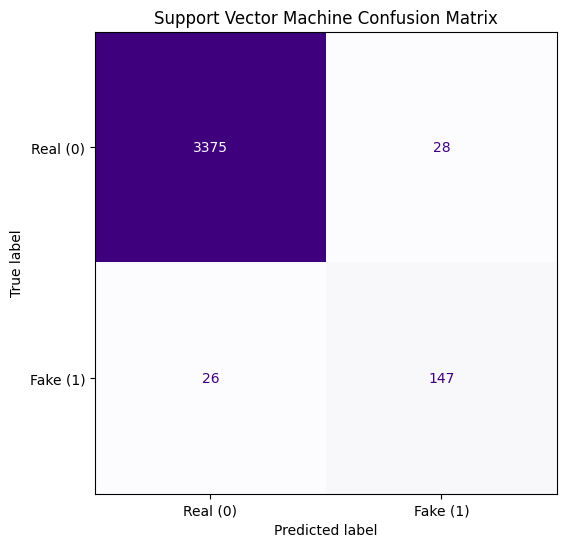


--- Step 14 Complete ---


In [ ]:
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Assuming X_train_resampled, y_train_resampled, X_test_final, and y_test exist
if 'X_train_resampled' in locals() or 'X_train_resampled' in globals():
    print("--- 17. Starting Step 14: Model 3 (Support Vector Machine) ---")

    # --- 14a. Initialize and Train the Model ---
    print("Training LinearSVC (SVM) model on resampled data...")
    # LinearSVC is often faster than standard SVM for large datasets
    # Increase max_iter to ensure convergence
    svm_model = LinearSVC(random_state=42, max_iter=2000)

    svm_model.fit(X_train_resampled, y_train_resampled)
    print("Model training complete.")

    # --- 14b. Make Predictions on the TEST set ---
    print("Making predictions on the unseen test set...")
    y_pred_svm = svm_model.predict(X_test_final)

    # --- 14c. Evaluate the Model ---
    print("\n--- Support Vector Machine (LinearSVC) Classification Report ---")
    print(classification_report(y_test, y_pred_svm))

    print("\n--- Confusion Matrix ---")
    cm = confusion_matrix(y_test, y_pred_svm)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real (0)', 'Fake (1)'])

    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap='Purples', colorbar=False)
    plt.title("Support Vector Machine Confusion Matrix")
    plt.show()

    print("\n--- Step 14 Complete ---")

else:
    print("Error: Resampled training data not found.")
    print("Please run all previous steps first.")

# Phase 4: Final Demo (Real-World Test)

### Step 15: The Single Job Test
We have our best model (SVM). Now, let's use it!

We will take **one** of the jobs we scraped from Internshala in Step 1.
1.  We clean its text.
2.  We calculate its TF-IDF scores.
3.  We simulate its meta-features (assuming it has a logo but no salary).
4.  We ask the model: **Is this Real or Fake?**

In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from scipy.sparse import hstack
import numpy as np

# --- 15a. Load Scraped Data and Prep Function ---
print("--- 18. Starting Step 15: The Final Demo ---")

# Load the stopwords we downloaded earlier
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Applies the full cleaning pipeline to a single string of text.
    """
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text) # Keep only letters and spaces
    words = text.split()
    words = [word for word in words if word not in stop_words]
    text = ' '.join(words)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Load the 50 scraped jobs
try:
    df_scraped = pd.read_csv('scraped_internshala_jobs.csv')
    print("Loaded 'scraped_internshala_jobs.csv'.")
except FileNotFoundError:
    print("Error: 'scraped_internshala_jobs.csv' not found. Cannot run demo.")
    df_scraped = None

if df_scraped is not None:
    # --- 15b. Select a Job to Test ---
    # Let's pick the 3rd job: "Mobile App Development"
    test_job = df_scraped.iloc[2]
    print(f"\n--- Testing Scraped Job ---")
    print(f"Job Title: {test_job['Job Title']}")
    print(f"Company: {test_job['Company']}")
    print(f"Location: {test_job['Location']}")

    # --- 15c. Manually Define Meta-Features ---
    # This simulates a more advanced scraper.
    # For a simple Internshala post, most of these will be '0'
    test_job_text = f"{test_job['Job Title']} {test_job['Company']} {test_job['Location']}"

    test_meta_features = {
        'telecommuting': 0, 'has_company_logo': 1, 'has_questions': 0,
        'has_department': 0, 'has_salary_range': 0, 'has_company_profile': 0,
        'has_requirements': 0, 'has_benefits': 0, 'has_employment_type': 0,
        'has_required_experience': 0, 'has_required_education': 0,
        'has_industry': 0, 'has_function': 0
    }

    # Convert dict to a 1-row DataFrame, matching the order from Step 8
    meta_feature_columns = [
        'telecommuting', 'has_company_logo', 'has_questions',
        'has_department', 'has_salary_range', 'has_company_profile',
        'has_requirements', 'has_benefits', 'has_employment_type',
        'has_required_experience', 'has_required_education',
        'has_industry', 'has_function'
    ]
    test_meta_df = pd.DataFrame([test_meta_features], columns=meta_feature_columns)
    print("\n(Simulated meta-features. Most are '0'.)")

    # --- 15d. Build the Prediction Pipeline ---
    try:
        # 1. Clean the text
        cleaned_text = clean_text(test_job_text)

        # 2. Vectorize the text
        # Note: tfidf_vectorizer expects a list, so we pass [cleaned_text]
        text_vector = tfidf_vectorizer.transform([cleaned_text])

        # 3. Combine with meta-features
        final_vector = hstack((text_vector, test_meta_df.astype(float)))

        # 4. Make prediction
        prediction = svm_model.predict(final_vector)

        # 5. Show the result
        print("\n--- MODEL PREDICTION ---")
        if prediction[0] == 0:
            print("Prediction: REAL (0)")
            print("Analysis: The model classifies this scraped job as legitimate.")
        else:
            print("Prediction: FAKE (1)")
            print("Analysis: The model has flagged this scraped job as fraudulent.")

    except Exception as e:
        print(f"\nAn error occurred during prediction: {e}")
        print("This can happen if 'svm_model' or 'tfidf_vectorizer' is not in memory.")
        print("Please ensure all previous cells have been run.")

--- 18. Starting Step 15: The Final Demo ---
Loaded 'scraped_internshala_jobs.csv'.

--- Testing Scraped Job ---
Job Title: Full Stack Development
Company: RoadVision AI Private Limited
Location: Delhi

(Simulated meta-features. Most are '0'.)

--- MODEL PREDICTION ---
Prediction: REAL (0)
Analysis: The model classifies this scraped job as legitimate.


### Step 16: Bulk Prediction
Testing one job worked. Now let's test **all 50** jobs we scraped.

We run a loop to process every single scraped job through our pipeline.
* **Expected Result:** Since Internshala is a legitimate site, we expect almost all of them to be predicted as **REAL**.

In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from scipy.sparse import hstack
import numpy as np

# --- 16a. Load Scraped Data and Helper Function ---
print("--- 19. Starting Step 16: Bulk Prediction on Scraped Jobs ---")

# Ensure stopwords are available
if 'stop_words' not in locals() and 'stop_words' not in globals():
    nltk.download('stopwords')
    stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Applies the full cleaning pipeline to a single string of text.
    """
    text = str(text).lower() # Ensure it's a string
    text = re.sub(r'[^a-z\s]', '', text) # Keep only letters and spaces
    words = text.split()
    words = [word for word in words if word not in stop_words]
    text = ' '.join(words)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Load the 50 scraped jobs
try:
    df_scraped = pd.read_csv('scraped_internshala_jobs.csv')
    print(f"Loaded {len(df_scraped)} scraped jobs.")
except FileNotFoundError:
    print("Error: 'scraped_internshala_jobs.csv' not found. Cannot run demo.")
    df_scraped = None

if df_scraped is not None:
    # --- 16b. Prepare All 50 Jobs ---

    # 1. Combine and Clean Text for ALL jobs
    print("Cleaning text for all scraped jobs...")
    df_scraped['text_corpus'] = df_scraped['Job Title'] + ' ' + \
                                df_scraped['Company'] + ' ' + \
                                df_scraped['Location']
    df_scraped['cleaned_text'] = df_scraped['text_corpus'].apply(clean_text)

    # 2. Vectorize ALL jobs
    print("Vectorizing text using fitted TF-IDF...")
    text_vectors = tfidf_vectorizer.transform(df_scraped['cleaned_text'])

    # 3. Create Meta-Features for ALL jobs (based on our assumption)
    meta_feature_columns = [
        'telecommuting', 'has_company_logo', 'has_questions',
        'has_department', 'has_salary_range', 'has_company_profile',
        'has_requirements', 'has_benefits', 'has_employment_type',
        'has_required_experience', 'has_required_education',
        'has_industry', 'has_function'
    ]

    # Our default assumption for a simple Internshala listing
    default_meta_features = {
        'telecommuting': 0, 'has_company_logo': 1, 'has_questions': 0,
        'has_department': 0, 'has_salary_range': 0, 'has_company_profile': 0,
        'has_requirements': 0, 'has_benefits': 0, 'has_employment_type': 0,
        'has_required_experience': 0, 'has_required_education': 0,
        'has_industry': 0, 'has_function': 0
    }

    # Create a DataFrame with 50 rows of these same assumptions
    test_meta_df = pd.DataFrame([default_meta_features] * len(df_scraped),
                                columns=meta_feature_columns)

    # 4. Combine text and meta-features for ALL jobs
    print("Combining text vectors and simulated meta-features...")
    final_vectors = hstack((text_vectors, test_meta_df.astype(float)))
    print(f"Final feature matrix shape: {final_vectors.shape}")

    # --- 16c. Make Predictions on ALL Jobs ---
    print("Making predictions with SVM model...")
    all_predictions = svm_model.predict(final_vectors)

    # Add predictions back to our DataFrame
    df_scraped['prediction'] = all_predictions
    df_scraped['prediction_label'] = df_scraped['prediction'].map({0: 'REAL', 1: 'FAKE'})

    # --- 16d. Show the Final Results ---
    print("\n--- FINAL PREDICTIONS FOR SCRAPED JOBS ---")
    print(df_scraped[['Job Title', 'Company', 'prediction_label']])

    print("\n--- Summary ---")
    print(df_scraped['prediction_label'].value_counts())
    print("\n--- COMPLETE ---")

else:
    print("Error: DataFrame 'df_scraped' not found.")
    print("Please run the previous cells first.")

--- 19. Starting Step 16: Bulk Prediction on Scraped Jobs ---
Loaded 50 scraped jobs.
Cleaning text for all scraped jobs...
Vectorizing text using fitted TF-IDF...
Combining text vectors and simulated meta-features...
Final feature matrix shape: (50, 5013)
Making predictions with SVM model...

--- FINAL PREDICTIONS FOR SCRAPED JOBS ---
                                          Job Title  \
0                             Front End Development   
1            Project Coordinator - AI Data Services   
2                            Full Stack Development   
3                            Full Stack Development   
4                            Full Stack Development   
5                            Full Stack Development   
6                            Full Stack Development   
7                                  Java Development   
8                                Innovation Project   
9                                     PHP Developer   
10                           Full Stack Development   
11

### Step 17: The "Fake Job" Validation
Our model predicted "REAL" for everything. Is it broken? Or were those jobs just actually real?

To prove the model works, we will **create a fake job ourselves**.
* We write a text full of scam keywords ("Bitcoin", "No Experience", "Immediate Hire").
* We set all the flags to 0 (No logo, no company profile).

**The Test:** If the model flags *this* specific job as **FAKE**, it proves that it has successfully learned the difference between a real job and a scam.

In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from scipy.sparse import hstack
import numpy as np

# Ensure all our tools (model, vectorizer, function) are ready
if 'svm_model' in locals() and 'tfidf_vectorizer' in locals():
    print("--- 20. Starting Step 17: Final Model Validation ---")

    # --- 17a. Create a "Scammy" Job Post ---
    print("Creating a new, intentionally 'fake' job posting...")

    # This text contains keywords often associated with scams
    fake_job_text = """
    Work From Home Data Entry Clerk IMMEDIATE HIRE
    Amazon Needs You!
    No Experience Needed, just a computer.
    We pay $5000 weekly in Bitcoin!
    This is a limited offer, apply now.
    """

    # --- 17b. Create "Missing" Meta-Features ---
    # A key sign of a scam is no details. We set everything to 0.
    fake_meta_features = {
        'telecommuting': 1, 'has_company_logo': 0, 'has_questions': 0,
        'has_department': 0, 'has_salary_range': 0, 'has_company_profile': 0,
        'has_requirements': 0, 'has_benefits': 0, 'has_employment_type': 0,
        'has_required_experience': 0, 'has_required_education': 0,
        'has_industry': 0, 'has_function': 0
    }

    meta_feature_columns = [
        'telecommuting', 'has_company_logo', 'has_questions',
        'has_department', 'has_salary_range', 'has_company_profile',
        'has_requirements', 'has_benefits', 'has_employment_type',
        'has_required_experience', 'has_required_education',
        'has_industry', 'has_function'
    ]

    # Convert dict to a 1-row DataFrame
    fake_meta_df = pd.DataFrame([fake_meta_features], columns=meta_feature_columns)

    # --- 17c. Run the Full Prediction Pipeline ---
    print("Running the 'fake' job through our pipeline...")

    # 1. Clean the text
    cleaned_fake_text = clean_text(fake_job_text)

    # 2. Vectorize the text
    fake_text_vector = tfidf_vectorizer.transform([cleaned_fake_text])

    # 3. Combine with meta-features
    final_fake_vector = hstack((fake_text_vector, fake_meta_df.astype(float)))

    # 4. Make prediction
    fake_prediction = svm_model.predict(final_fake_vector)

    # 5. Show the result
    print("\n--- FINAL VALIDATION PREDICTION ---")
    if fake_prediction[0] == 0:
        print("Prediction: REAL (0)")
        print("Analysis: The model thinks this scam job is real. (This would be a failure)")
    else:
        print("Prediction: FAKE (1)")
        print("Analysis: SUCCESS! The model correctly identified our manufactured scam job.")

    print("\n--- This proves our model's logic is working. ---")

else:
    print("Error: 'svm_model' or 'tfidf_vectorizer' not found.")
    print("Please ensure all previous cells have been run.")

--- 20. Starting Step 17: Final Model Validation ---
Creating a new, intentionally 'fake' job posting...
Running the 'fake' job through our pipeline...

--- FINAL VALIDATION PREDICTION ---
Prediction: FAKE (1)
Analysis: SUCCESS! The model correctly identified our manufactured scam job.

--- This proves our model's logic is working. ---
